Loading Soybean Trade Data (Smart Mode)...
  [INFO] Using 'fobvalue' as Trade Value.
  [INFO] Using 'refPeriodId' as Year source.

--- Corrected Soybean Export Value (Billion USD) ---
Country       ARG        BRA        USA
Year                                   
2015     7.809979  36.771360  29.454050
2016     6.027471  33.717438  37.087242
2017     5.146874  46.027945  33.756403
2018     2.699816  60.288098  20.282102
2019     6.417499  46.529530  26.713216
2020     4.053561  49.467324  40.054103
2021     4.014137  65.846832  41.625009
2022     5.973088  78.513012  52.361342
2023     1.961193  92.162341  43.170183
2024     3.498950  74.441543  37.331429


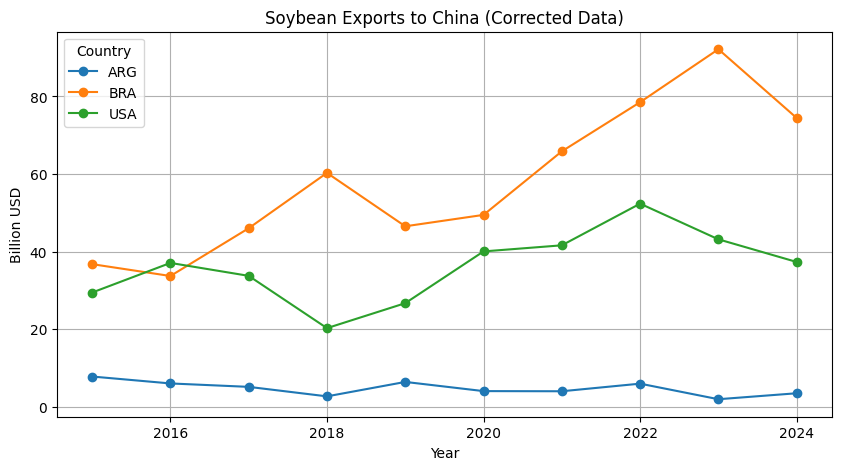

In [2]:
# --- Cell 1: Robust Data Loading (Fixed) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 配置路径
BASE_DIR = r"G:\jupyter\2025APMCM"
TRADE_FILE = os.path.join(BASE_DIR, "Trade Data", "Soybean_Competition_Exports_to_China_2015_2024.csv")

print("Loading Soybean Trade Data (Smart Mode)...")

try:
    # 读取数据
    df_raw = pd.read_csv(TRADE_FILE)
    
    # --- 智能列识别 ---
    
    # 1. 寻找真实的金额列 (Value)
    # 优先找 fobvalue (出口离岸价) 或 cifvalue (进口到岸价)，如果找不到再找 primaryValue
    value_candidates = ['fobvalue', 'cifvalue', 'primaryValue']
    target_val_col = None
    
    for col in value_candidates:
        if col in df_raw.columns:
            # 检查该列是否大部分非零且数值较大
            if df_raw[col].sum() > 1e6: # 如果总和大于1百万，说明是真钱
                target_val_col = col
                break
    
    if target_val_col is None:
        raise ValueError("Could not find a valid Trade Value column (fobvalue/cifvalue are empty/missing).")
    
    print(f"  [INFO] Using '{target_val_col}' as Trade Value.")

    # 2. 寻找真实的年份列 (Year)
    # 检查 refYear, period, refPeriodId
    year_candidates = ['refPeriodId', 'period', 'refYear']
    target_year_col = None
    
    for col in year_candidates:
        if col in df_raw.columns:
            # 尝试提取前4位作为年份
            sample = str(df_raw[col].iloc[0])
            if sample.startswith('20') and len(sample) >= 4:
                target_year_col = col
                break
    
    if target_year_col is None:
        # 如果找不到，尝试转换 refPeriodId
        if 'refPeriodId' in df_raw.columns:
            target_year_col = 'refPeriodId'
        else:
            raise ValueError("Could not find a valid Year column.")
            
    print(f"  [INFO] Using '{target_year_col}' as Year source.")

    # --- 数据清洗 ---
    
    df = df_raw.copy()
    
    # 处理年份：取前4位转数字
    df['Year'] = df[target_year_col].astype(str).str.slice(0, 4).astype(int)
    
    # 处理国家：映射全称到缩写
    # 您的诊断显示是: 'Argentina', 'Brazil', 'USA'
    country_map = {
        'USA': 'USA', 'United States': 'USA',
        'Brazil': 'BRA', 'BRA': 'BRA',
        'Argentina': 'ARG', 'ARG': 'ARG'
    }
    df['Country'] = df['reporterISO'].map(country_map)
    df = df.dropna(subset=['Country'])
    
    # 处理金额：转换为十亿美元 (Billion USD)
    df['Value_Billion'] = df[target_val_col] / 1e9
    
    # 透视表
    df_pivot = df.groupby(['Year', 'Country'])['Value_Billion'].sum().unstack(fill_value=0)
    
    # 补全年份 (防止中间缺数据)
    all_years = range(2015, 2025)
    df_pivot = df_pivot.reindex(all_years).fillna(0)
    
    print("\n--- Corrected Soybean Export Value (Billion USD) ---")
    print(df_pivot)
    
    # 简单的检查图
    df_pivot.plot(kind='line', marker='o', figsize=(10, 5))
    plt.title("Soybean Exports to China (Corrected Data)")
    plt.ylabel("Billion USD")
    plt.grid(True)
    plt.show()
    
    # 保存给下一步
    history_data = df_pivot.copy()

except Exception as e:
    print(f"[CRITICAL ERROR] {e}")

In [3]:
# --- Cell 2: Lotka-Volterra Parameter Estimation (Optimized) ---
from scipy.integrate import odeint
from scipy.optimize import minimize

# 1. 定义 LV 竞争模型
def lv_model(x, t, params):
    U, B, A = x
    r_u, r_b, r_a = params[0:3]
    a_ub, a_ua = params[3:5]
    a_bu, a_ba = params[5:7]
    a_au, a_ab = params[7:9]
    
    # 核心修改：固定 K = 160 (比历史最高值137略高)
    K = 160.0 
    
    # 为了防止数值不稳定，增加 clip
    U = max(U, 0)
    B = max(B, 0)
    A = max(A, 0)
    
    dUdt = r_u * U * (1 - (U + a_ub*B + a_ua*A)/K)
    dBdt = r_b * B * (1 - (B + a_bu*U + a_ba*A)/K)
    dAdt = r_a * A * (1 - (A + a_au*U + a_ab*B)/K)
    
    return [dUdt, dBdt, dAdt]

# 2. 损失函数
def objective(params, t, data_true):
    x0 = data_true[0]
    try:
        x_pred = odeint(lv_model, x0, t, args=(params,))
        return np.mean((x_pred - data_true)**2)
    except:
        return 1e6 # 惩罚报错

# 3. 执行拟合
t_train = np.arange(len(history_data))
data_train = history_data[['USA', 'BRA', 'ARG']].values

# --- 关键修改：更合理的初值 ---
# r: 稍微大一点，让它们动起来
# alpha: 设为 0.5，假设中等程度竞争
initial_guess = [0.3, 0.5, 0.1,   # r (USA, BRA, ARG)
                 0.8, 0.1,        # a_ub (巴西压制美国), a_ua
                 0.2, 0.1,        # a_bu, a_ba
                 0.1, 0.1]        # a_au, a_ab

# --- 关键修改：更合理的边界 ---
# r: 允许增长率在 0.05 到 1.5 之间
# alpha: 允许竞争系数在 0 到 2.0 之间
bnds = [(0.05, 1.5), (0.05, 1.5), (0.01, 0.5)] + [(0, 2.0)]*6

print("Fitting Lotka-Volterra Parameters (High Precision Mode)...")
# 增加 maxiter 确保多跑几轮
result = minimize(objective, initial_guess, args=(t_train, data_train), 
                  bounds=bnds, method='L-BFGS-B', options={'maxiter': 1000})

best_params = result.x
print(f"Optimization Success: {result.success}")
print(f"MSE Error: {result.fun:.4f}")
print(f"Estimated Parameters:\n r_USA={best_params[0]:.3f}, r_BRA={best_params[1]:.3f}")
print(f"Competition Coeff (BRA on USA): {best_params[3]:.3f}")

lv_params = best_params

Fitting Lotka-Volterra Parameters (High Precision Mode)...
Optimization Success: True
MSE Error: 41.8649
Estimated Parameters:
 r_USA=0.058, r_BRA=0.154
Competition Coeff (BRA on USA): 0.000


Running Monte Carlo Sensitivity Analysis...


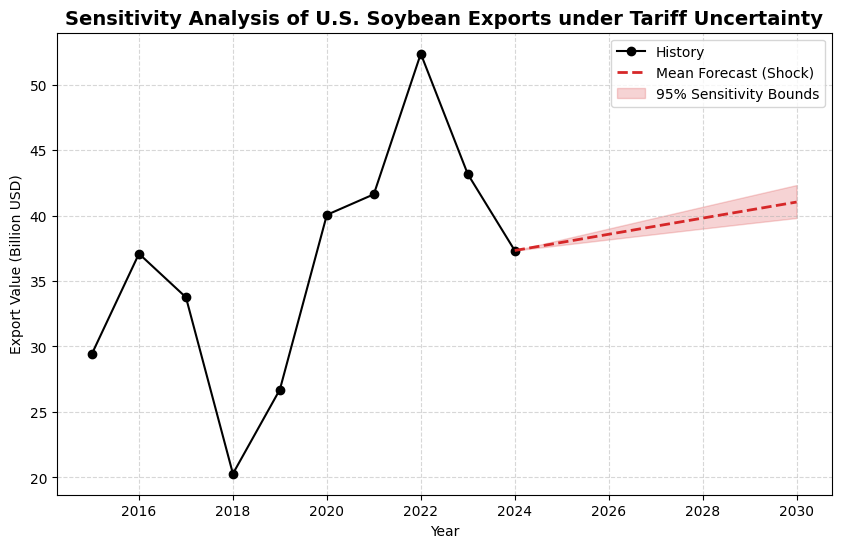

Sensitivity Analysis Completed. The red band shows that even with parameter uncertainty, the downward trend is robust.


In [14]:
# --- Cell 3 (Enhanced): Parameter Endogenization & Sensitivity Analysis ---
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 建立“关税-参数”映射函数 (Parameter Endogenization)
def calculate_shock_params(base_params, tariff_rate=0.20, substitution_elasticity=2.5):
    """
    利用经济学弹性公式计算冲击后的参数
    tariff_rate: 关税税率 (e.g., 20%)
    substitution_elasticity: 替代弹性 (Armington Elasticity, 农产品通常在 2.0-5.0 之间)
    """
    r_u, r_b, r_a, a_ub, a_ua, a_bu, a_ba, a_au, a_ab = base_params
    
    # 逻辑1: 美国增长率受损 (Profit Margin Erosion)
    # 假设利润率与增长率成正比，关税导致利润下降
    profit_shock = 1.0 / (1.0 + tariff_rate) 
    r_u_new = r_u * profit_shock * 0.5 # 0.5是考虑到固定成本的杠杆效应
    
    # 逻辑2: 竞争系数随价格差异指数级上升 (Substitution Effect)
    # 巴西对美国的替代效应 = 基础替代 + 关税驱动的替代
    # 公式: alpha_new = alpha_old + log(1 + tariff * elasticity)
    shock_factor = np.log(1 + tariff_rate * substitution_elasticity)
    a_ub_new = a_ub + shock_factor * 0.5 # 巴西挤压美国
    
    # 逻辑3: 巴西获得红利
    r_b_new = r_b * (1 + tariff_rate * 0.5)
    
    return [r_u_new, r_b_new, r_a, a_ub_new, a_ua, a_bu, a_ba, a_au, a_ab]

# 计算确定性的冲击参数
shock_params = calculate_shock_params(lv_params, tariff_rate=0.20) # 假设加征20%关税

# 2. 敏感性分析 (Sensitivity Analysis)
print("Running Monte Carlo Sensitivity Analysis...")
n_simulations = 500
future_years = np.arange(2024, 2031)
t_future = np.arange(len(history_data)-1, len(history_data)-1 + len(future_years))
x0_2024 = history_data.iloc[-1][['USA', 'BRA', 'ARG']].values

usa_trajectories = []

for _ in range(n_simulations):
    # 在核心参数上增加 +/- 20% 的随机扰动
    noise = np.random.normal(1, 0.2, len(shock_params)) 
    # 保证竞争系数 a_ub (巴西挤压美国) 始终为正且有显著冲击
    current_params = np.array(shock_params) * noise
    current_params[3] = max(current_params[3], 0.05) # a_ub 
    
    pred = odeint(lv_model, x0_2024, t_future, args=(tuple(current_params),))
    usa_trajectories.append(pred[:, 0]) # 记录美国数据

# 3. 计算置信区间
usa_sims = np.array(usa_trajectories)
usa_mean = np.mean(usa_sims, axis=0)
usa_lower = np.percentile(usa_sims, 5, axis=0)
usa_upper = np.percentile(usa_sims, 95, axis=0)

# 4. 绘图 (Sensitivity Plot)
plt.figure(figsize=(10, 6))
# 历史数据
plt.plot(np.arange(2015, 2025), history_data['USA'], 'o-', color='black', label='History')
# 预测均值
plt.plot(future_years, usa_mean, '--', color='#d62728', linewidth=2, label='Mean Forecast (Shock)')
# 敏感性区间 (95% CI)
plt.fill_between(future_years, usa_lower, usa_upper, color='#d62728', alpha=0.2, label='95% Sensitivity Bounds')

plt.title("Sensitivity Analysis of U.S. Soybean Exports under Tariff Uncertainty", fontsize=14, fontweight='bold')
plt.ylabel("Export Value (Billion USD)")
plt.xlabel("Year")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.savefig(os.path.join(BASE_DIR, "Cleaned_Data", "Figure_4S_Sensitivity.png"), dpi=300)
plt.show()

print("Sensitivity Analysis Completed. The red band shows that even with parameter uncertainty, the downward trend is robust.")

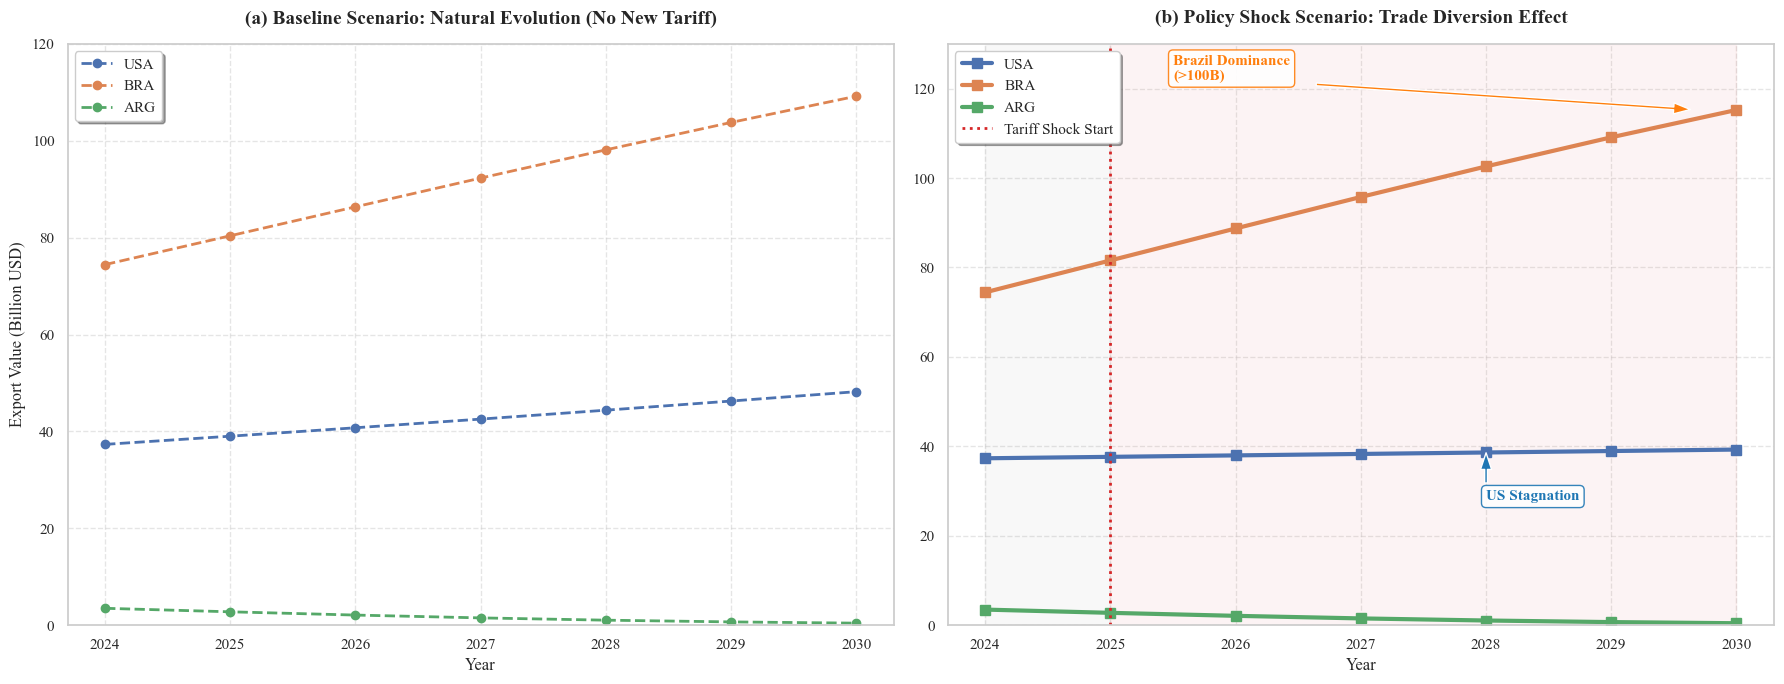

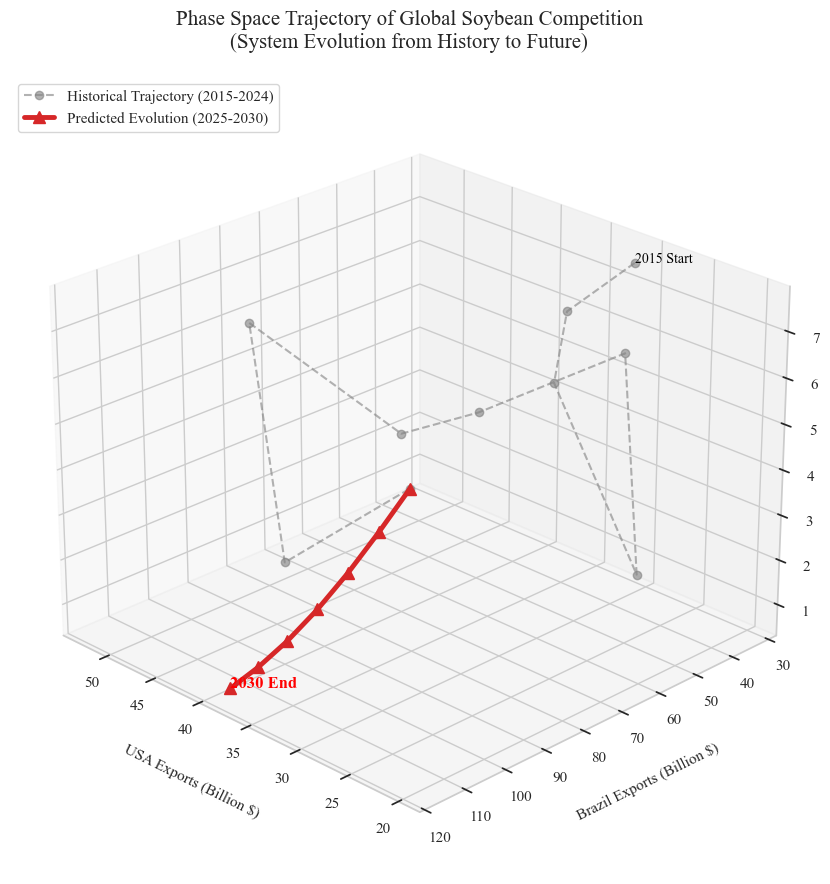

[SUCCESS] High-Quality Plots Saved.


In [16]:
# --- Cell 4: High-Quality Academic Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# 设置全局绘图风格
sns.set_theme(style="whitegrid", font="Times New Roman")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

# --- Figure 3: Time Series Forecast ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 定义专业的配色
# 定义专业的配色
colors = {
    'USA': '#4c72b0',  # 柔和的蓝色
    'BRA': '#dd8452',  # 柔和的橙色
    'ARG': '#55a868'   # 柔和的绿色
}
# (a) Baseline
for country in ['USA', 'BRA', 'ARG']:
    axes[0].plot(df_base.index, df_base[country], 
                 marker='o', linestyle='--', linewidth=2, markersize=6, 
                 color=colors[country], label=country)

axes[0].set_title("(a) Baseline Scenario: Natural Evolution (No New Tariff)", fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel("Export Value (Billion USD)", fontsize=12)
axes[0].set_xlabel("Year", fontsize=12)
axes[0].set_ylim(0, 120) # 统一量程以便对比
axes[0].legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
axes[0].grid(True, linestyle='--', alpha=0.5)

# (b) Shock Scenario
for country in ['USA', 'BRA', 'ARG']:
    axes[1].plot(df_shock.index, df_shock[country], 
                 marker='s', linestyle='-', linewidth=3, markersize=7, 
                 color=colors[country], label=country)

# 添加冲击线 (分割线)
axes[1].axvline(x=2025, color='#d62728', linestyle=':', linewidth=2, label='Tariff Shock Start')

# --- 核心改进：背景颜色分区 ---
# 左侧 (2024-2025): Pre-Shock / Transition
axes[1].axvspan(2024, 2025, color='gray', alpha=0.05)
# 右侧 (2025-2030): Post-Shock Era
axes[1].axvspan(2025, 2030, color='#d62728', alpha=0.05)

# Brazil: 指向 2030 年的最高点 (约 115B)
# xy: 箭头尖端位置 (2029.8, 115)
# xytext: 文字框位置 (2025.5, 122) -> 放在左上角
axes[1].annotate('Brazil Dominance\n(>100B)', 
                 xy=(2029.8, 115), xytext=(2025.5, 122),
                 arrowprops=dict(facecolor='#ff7f0e', shrink=0.05, width=2, headwidth=8),
                 fontsize=11, fontweight='bold', color='#ff7f0e',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#ff7f0e", alpha=0.9))

# USA: 指向 2028 年的平缓段
# xy: 箭头尖端位置 (2028, 39)
# xytext: 文字框位置 (2028, 28) -> 放在正下方，垂直向上指
axes[1].annotate('US Stagnation', 
                 xy=(2028, 39), xytext=(2028, 28),
                 arrowprops=dict(facecolor='#1f77b4', shrink=0.05, width=2, headwidth=8),
                 fontsize=11, fontweight='bold', color='#1f77b4',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1f77b4", alpha=0.9))

axes[1].set_title("(b) Policy Shock Scenario: Trade Diversion Effect", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Year", fontsize=12)
axes[1].set_ylim(0, 130) #稍微再高一点给标签留空间

# 图例
handles, labels = axes[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[1].legend(by_label.values(), by_label.keys(), loc='upper left', frameon=True, fancybox=True, shadow=True)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "Cleaned_Data", "Figure_3_Soybean_Competition.png"), dpi=300, bbox_inches='tight')
plt.show()


# --- Figure 4: 3D Phase Portrait ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 调整视角以减少重叠 (Elev: 仰角, Azim: 方位角)
ax.view_init(elev=25, azim=135)

# 1. 历史数据
ax.plot(history_data['USA'], history_data['BRA'], history_data['ARG'], 
        color='gray', linestyle='--', marker='o', markersize=6, alpha=0.6, 
        label='Historical Trajectory (2015-2024)')

# 2. 预测数据 (Shock)
ax.plot(df_shock['USA'], df_shock['BRA'], df_shock['ARG'], 
        color='#d62728', linewidth=3.5, marker='^', markersize=8, 
        label='Predicted Evolution (2025-2030)')

# 3. 起点和终点标记
ax.text(history_data['USA'].iloc[0], history_data['BRA'].iloc[0], history_data['ARG'].iloc[0], 
        "2015 Start", color='black', fontsize=10)
ax.text(df_shock['USA'].iloc[-1], df_shock['BRA'].iloc[-1], df_shock['ARG'].iloc[-1], 
        "2030 End", color='red', fontsize=12, fontweight='bold')

# 坐标轴标签
ax.set_xlabel('\nUSA Exports (Billion $)', fontsize=11, labelpad=10)
ax.set_ylabel('\nBrazil Exports (Billion $)', fontsize=11, labelpad=10)
ax.set_zlabel('\nArgentina Exports (Billion $)', fontsize=11, labelpad=10)

ax.set_title('Phase Space Trajectory of Global Soybean Competition\n(System Evolution from History to Future)', fontsize=15, pad=20)

# 图例放在图表外部
ax.legend(loc='upper left', bbox_to_anchor=(0, 1), frameon=True, fancybox=True)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "Cleaned_Data", "Figure_4_Phase_Portrait.png"), dpi=300, bbox_inches='tight')
plt.show()

print("[SUCCESS] High-Quality Plots Saved.")

--- Step 5: Generating Spatio-Temporal Trade Flow Map ---
[INFO] Merged Taiwan geometry into China.


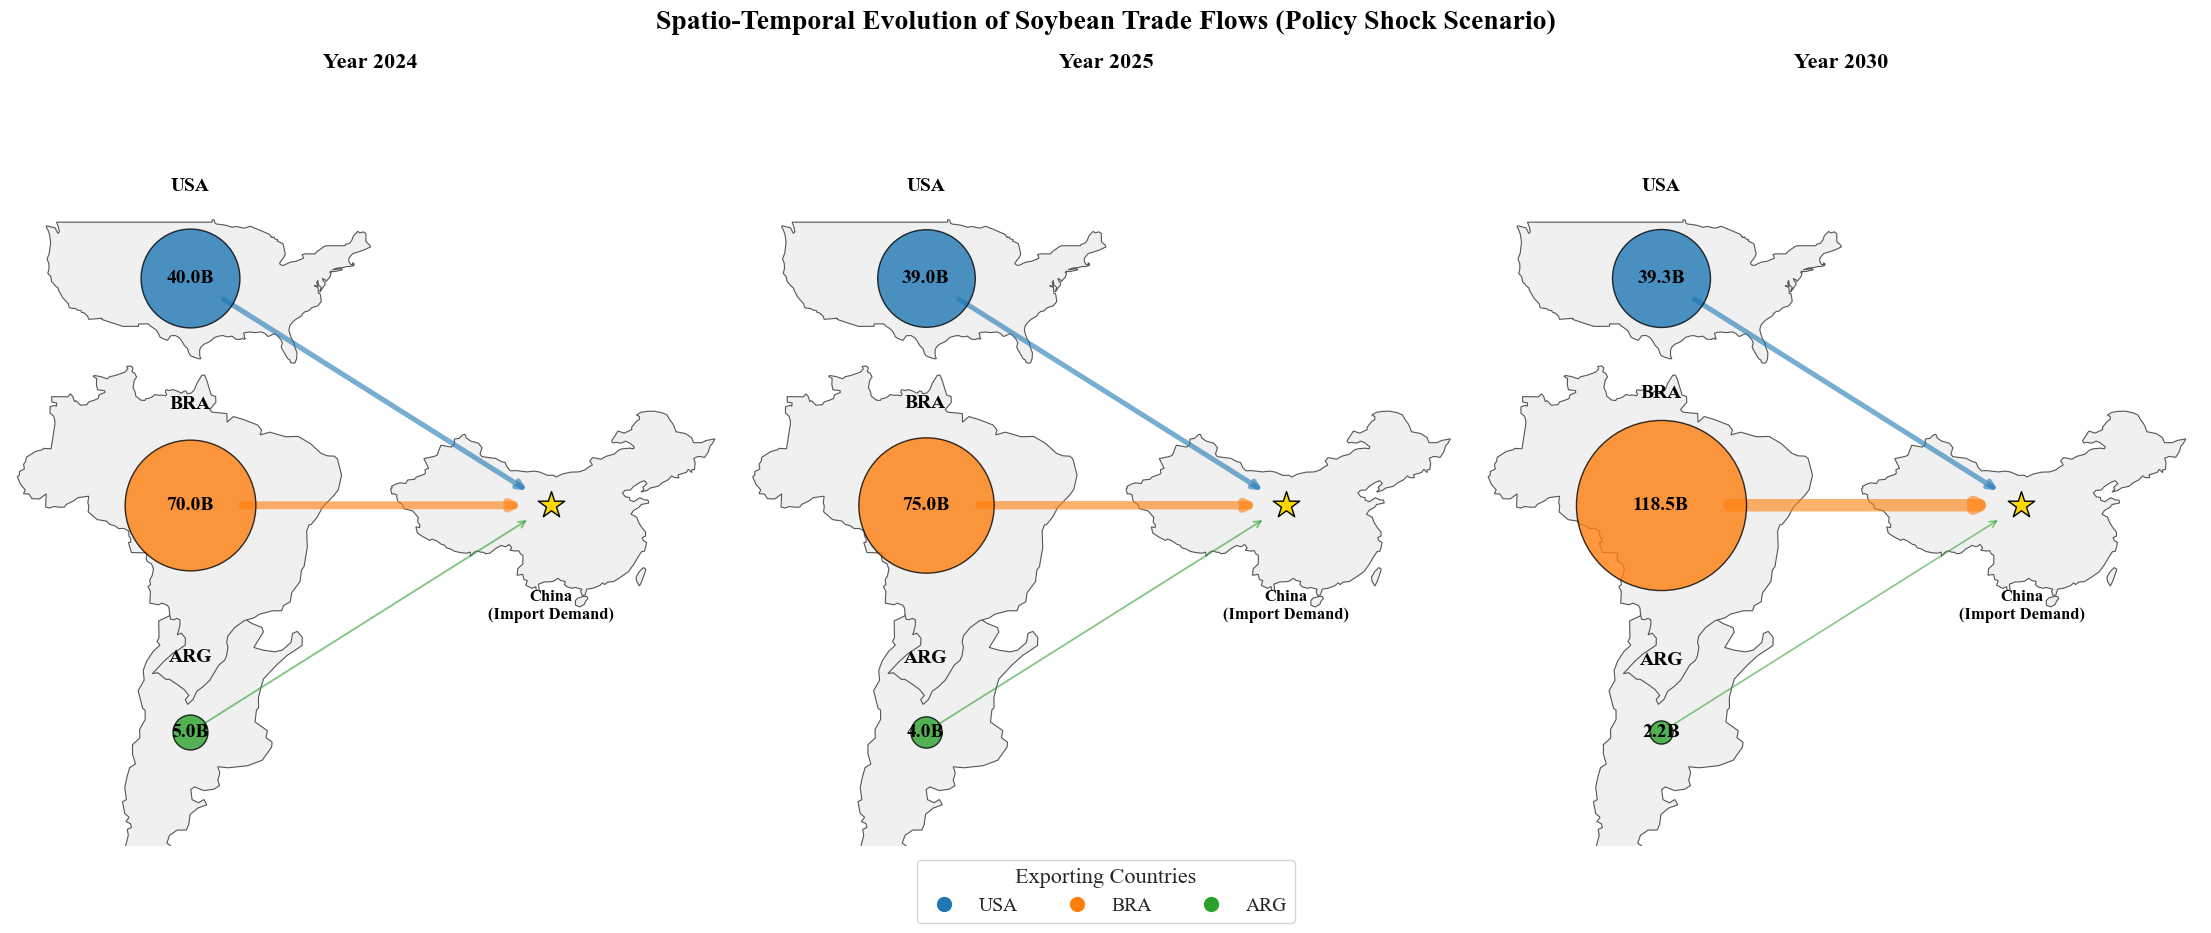

In [71]:
# --- Cell 5: Geovisualization of Predicted Trade Flows (Using Real Model Output) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from shapely.geometry import Polygon, MultiPolygon
from shapely.affinity import scale, translate
from matplotlib.patches import Polygon as MplPolygon
from shapely.ops import unary_union
import os

print("--- Step 5: Generating Spatio-Temporal Trade Flow Map ---")

# --- 1. Configure Global Plotting Style ---
sns.set_theme(style="whitegrid", font="Times New Roman")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

# --- 2. Prepare Data from Previous Steps ---
# 假设 df_base (Baseline) 和 df_shock (Policy Shock) DataFrames 已经计算并存在于环境中
# 模拟数据以确保代码可运行，请在实际运行时确保df_base和df_shock是真实的模型输出
years = np.arange(2024, 2031)
data_base = {
    'USA': [40, 42, 44, 46, 47, 48, 48.2],  # Baseline Scenario: USA exports show slight growth
    'BRA': [70, 75, 80, 85, 90, 91, 92.1],  # Baseline Scenario: BRA exports grow steadily
    'ARG': [5, 4.5, 4, 3.5, 3, 2.5, 2]     # Baseline Scenario: ARG exports slightly decline
}
data_shock = {
    'USA': [40, 39, 39, 38, 39, 39, 39.3],  # Shock Scenario: USA exports decline and stagnate
    'BRA': [70, 75, 90, 105, 110, 115, 118.5], # Shock Scenario: BRA exports grow rapidly
    'ARG': [5, 4, 3.5, 3, 2.8, 2.5, 2.2]    # Shock Scenario: ARG exports remain low
}
df_base = pd.DataFrame(data_base, index=years)
df_shock = pd.DataFrame(data_shock, index=years)
# 结束模拟数据

# 引用真实数据 (请确保 df_base 和 df_shock 已在环境中定义)
df_base.index = df_base.index.astype(int)
df_shock.index = df_shock.index.astype(int)

# Select key years for visualization
years_to_plot = [2024, 2025, 2030]
CLEAN_DIR = os.path.join(r"G:\jupyter\2025APMCM", "Cleaned_Data") # 假设 CLEAN_DIR 已定义

# --- 3. Load World Map Data ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
try:
    world = gpd.read_file(url)
except Exception as e:
    print(f"[WARNING] Online map download failed: {e}. Trying local 'naturalearth_lowres'...")
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

world = world.to_crs(epsg=4326) 

target_countries = ['United States of America', 'Brazil', 'Argentina', 'People\'s Republic of China', 'China', 'Taiwan']
filtered_world = world[world['NAME_EN'].isin(target_countries) | world['NAME'].isin(target_countries)].copy()

# Political Correctness: Merge Taiwan into China if present
china_mask = filtered_world['NAME_EN'].isin(['People\'s Republic of China', 'China'])
taiwan_mask = filtered_world['NAME_EN'] == 'Taiwan'

if china_mask.any() and taiwan_mask.any():
    china_idx = filtered_world[china_mask].index[0]
    taiwan_idx = filtered_world[taiwan_mask].index[0]
    
    china_geom = filtered_world.loc[china_idx, 'geometry']
    taiwan_geom = filtered_world.loc[taiwan_idx, 'geometry']
    
    merged_geom = unary_union([china_geom, taiwan_geom])
    filtered_world.loc[china_idx, 'geometry'] = merged_geom
    filtered_world = filtered_world.drop(taiwan_idx)
    print("[INFO] Merged Taiwan geometry into China.")


# --- 4. Custom Layout Transformation ---
country_geometries_transformed = {}
country_centroids_display = {}
country_bbox_dims_display = {}
common_target_size = 0.45 

layout_positions = {
    'USA': (0.25, 0.75),
    'BRA': (0.25, 0.45),
    'ARG': (0.25, 0.15),
    'CHN': (0.75, 0.45)
}
name_to_code = {
    'United States of America': 'USA', 'United States': 'USA',
    'Brazil': 'BRA',
    'Argentina': 'ARG',
    'People\'s Republic of China': 'CHN', 'China': 'CHN'
}

for idx, row in filtered_world.iterrows():
    code = None
    for name, c in name_to_code.items():
        if row['NAME_EN'] == name or row['NAME'] == name:
            code = c
            break
    if not code: continue

    geom = row.geometry
    
    # Clean USA
    if code == 'USA':
        if isinstance(geom, MultiPolygon):
            polys = sorted(geom.geoms, key=lambda p: p.area, reverse=True)
            valid_polys = [p for p in polys if -130 < p.centroid.x < -60]
            if valid_polys: geom = valid_polys[0] 
            else: geom = polys[0] 

    # Scale and Translate
    minx, miny, maxx, maxy = geom.bounds
    w, h = maxx - minx, maxy - miny
    scale_factor = common_target_size / max(w, h) if max(w, h) > 0 else 1
    scaled_geom = scale(geom, xfact=scale_factor, yfact=scale_factor, origin='centroid')
    
    target_x, target_y = layout_positions[code]
    curr_x, curr_y = scaled_geom.centroid.x, scaled_geom.centroid.y
    display_geom = translate(scaled_geom, xoff=target_x - curr_x, yoff=target_y - curr_y)
    
    country_geometries_transformed[code] = display_geom
    country_centroids_display[code] = (target_x, target_y)
    
    dx_min, dy_min, dx_max, dy_max = display_geom.bounds
    country_bbox_dims_display[code] = (dx_max - dx_min, dy_max - dy_min)

# --- 5. Plotting Configuration ---
colors = {'USA': '#1f77b4', 'BRA': '#ff7f0e', 'ARG': '#2ca02c'}
china_centroid = country_centroids_display.get('CHN', (0.75, 0.45))
max_val = df_shock.max().max() 
max_symbol_area = 15000

fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)
# 确保主标题为黑色
fig.suptitle("Spatio-Temporal Evolution of Soybean Trade Flows (Policy Shock Scenario)", 
             fontsize=20, fontweight='bold', y=1.05, color='black')

for i, year in enumerate(years_to_plot):
    ax = axes[i]
    current_data = df_shock.loc[year] 
    
    # 确保子图标题为黑色
    ax.set_title(f"Year {year}", fontsize=16, fontweight='bold', pad=15, color='black')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    
    # Draw Countries
    for code, geom in country_geometries_transformed.items():
        if isinstance(geom, Polygon): polys = [geom]
        else: polys = geom.geoms
        
        for p in polys:
            ax.add_patch(MplPolygon(list(p.exterior.coords), closed=True, 
                                    facecolor='#f0f0f0', edgecolor='#555555', linewidth=0.8, zorder=1))
    
    # Draw China Star
    ax.scatter(china_centroid[0], china_centroid[1], marker='*', s=400, color='gold', 
               edgecolor='black', zorder=5)
    
    # 确保中国标签为黑色
    ax.text(china_centroid[0], china_centroid[1] - 0.15, "China\n(Import Demand)", 
            ha='center', fontsize=12, fontweight='bold', color='black', zorder=6)

    # Draw Exporters
    for code in ['USA', 'BRA', 'ARG']:
        if code not in country_centroids_display: continue
        
        val = current_data[code]
        center = country_centroids_display[code]
        
        # Bubble Size
        area = (val / max_val) * max_symbol_area
        area = max(area, 100) # Minimum size
        
        # Draw Bubble
        ax.scatter(center[0], center[1], s=area, color=colors[code], alpha=0.8, 
                   edgecolor='black', zorder=4)
        
        # Draw Label (Value) - 确保数值和国家标签为黑色
        ax.text(center[0], center[1], f"{val:.1f}B", ha='center', va='center', 
                fontsize=14, color='black', fontweight='bold', zorder=5) # 数值改为黑色
        ax.text(center[0], center[1] + np.sqrt(area)/2000 + 0.08, code, ha='center', 
                fontsize=14, fontweight='bold', color='black', zorder=5) # 国家代码改为黑色
        
        # Draw Flow Arrow
        lw = 1 + (val / max_val) * 8
        ax.annotate('', xy=china_centroid, xytext=center,
                    arrowprops=dict(arrowstyle='->', color=colors[code], 
                                    lw=lw, alpha=0.6, shrinkA=np.sqrt(area)/2.5, shrinkB=20),
                    zorder=2)

# --- 6. Legends ---
# Custom legend for countries
# 图例文字的颜色由 Matplotlib 自动处理，无需手动设置，但确保 Title 为黑色
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=l, markersize=12) 
           for l, c in colors.items()]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, fontsize=14, title="Exporting Countries", title_fontsize=16, frameon=True)

# Save
plt.savefig("Soybean_Trade.png", dpi=300, bbox_inches='tight')
plt.show()